# 06 – Lead-to-Close Funnel Conversion Prediction
## Business Context
A home service contractor's revenue funnel:
```
Lead (inbound call/form) → Booking → Appointment → Estimate → JOB SOLD → Completed
```

At each stage there's drop-off. The **estimate-to-close** stage is the highest-leverage
ML target: a technician has invested time going to the customer's home and presenting a quote.
Will the customer buy?

Predicting this in real time (right after the estimate is created) enables:
- **Technician coaching**: surface a tip for low-probability estimates before the tech leaves
- **Office follow-up routing**: flag low-probability estimates for a callback within 24 hours
- **Funnel analytics**: identify which job types, markets, or technicians have conversion problems


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Synthetic Estimate Dataset ───────────────────────────────────────────────
N = 7000

job_type       = np.random.choice(['ac_repair','ac_install','furnace_repair',
                                    'furnace_install','drain','tune_up'], N,
                                   p=[0.25, 0.15, 0.20, 0.10, 0.15, 0.15])

# Price quoted vs. market benchmark
market_avg     = {'ac_repair': 350, 'ac_install': 3500, 'furnace_repair': 300,
                  'furnace_install': 3000, 'drain': 180, 'tune_up': 120}
market_prices  = np.array([market_avg[j] for j in job_type])
price_ratio    = np.random.lognormal(mean=0, sigma=0.25, size=N)  # quoted / market
price_quoted   = (market_prices * price_ratio).round(-1)

# Customer context
is_returning   = np.random.binomial(1, 0.40, N)
zip_income_q   = np.random.randint(1, 6, N)
equipment_age  = np.random.uniform(1, 20, N)
urgency        = np.random.choice(['low','medium','high','emergency'], N,
                                   p=[0.20, 0.40, 0.30, 0.10])
urgency_num    = {'low': 0, 'medium': 1, 'high': 2, 'emergency': 3}
urgency_val    = np.array([urgency_num[u] for u in urgency])

# Options presented (good-better-best improves conversion)
n_options_presented = np.random.choice([1, 2, 3], N, p=[0.3, 0.4, 0.3])
financing_offered   = np.random.binomial(1, 0.5, N)

# Technician closer score (some are better at the consultative sale)
tech_id        = np.random.randint(0, 20, N)
tech_close_rate = np.clip(np.random.normal(0.55, 0.12, 20), 0.2, 0.9)
tech_skill     = tech_close_rate[tech_id]

# --- True close probability ---
log_odds = (
    -0.5                               # baseline
    + 1.5 * is_returning               # returning customers convert better
    - 2.0 * np.log(price_ratio)        # above-market price hurts conversion
    + 0.3 * urgency_val                # urgency drives conversion
    + 0.2 * (equipment_age > 12)       # old equipment → more motivated
    + 0.4 * (n_options_presented == 3) # good-better-best works
    + 0.5 * financing_offered          # financing unlocks closed
    + 1.5 * (tech_skill - 0.55)       # better closer → higher conversion
    + 0.2 * (zip_income_q - 3)        # higher income → less price sensitivity
)
close_prob = 1 / (1 + np.exp(-log_odds))
closed = (np.random.random(N) < close_prob).astype(int)

df = pd.DataFrame({
    'job_type': job_type, 'price_quoted': price_quoted,
    'price_vs_market': price_ratio.round(3),
    'is_returning': is_returning, 'zip_income_q': zip_income_q,
    'equipment_age': equipment_age.round(1), 'urgency': urgency,
    'urgency_val': urgency_val, 'n_options_presented': n_options_presented,
    'financing_offered': financing_offered, 'tech_id': tech_id,
    'tech_skill': tech_skill.round(3), 'closed': closed
})

print(f"Dataset: {df.shape}")
print(f"Overall close rate: {df['closed'].mean():.1%}")
print("\nClose rate by job type:")
print(df.groupby('job_type')['closed'].mean().sort_values(ascending=False).round(3))


Dataset: (7000, 13)
Overall close rate: 68.4%

Close rate by job type:
job_type
tune_up            0.710
furnace_repair     0.702
ac_repair          0.676
ac_install         0.676
drain              0.666
furnace_install    0.664
Name: closed, dtype: float64


In [3]:
# ─── Model Training ───────────────────────────────────────────────────────────
features = ['price_vs_market', 'is_returning', 'zip_income_q', 'equipment_age',
            'urgency_val', 'n_options_presented', 'financing_offered', 'tech_skill']
X = df[features]
y = df['closed']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
                            verbosity=0, random_state=42)
model.fit(X_tr, y_tr)
probs = model.predict_proba(X_te)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_te, probs):.3f}")
print(f"PR-AUC:  {average_precision_score(y_te, probs):.3f}")
print(f"Brier:   {brier_score_loss(y_te, probs):.4f}  (lower is better, 0=perfect)")


ROC-AUC: 0.742
PR-AUC:  0.851
Brier:   0.2042  (lower is better, 0=perfect)


In [4]:
# ─── Business Integration: Coaching Triggers ────────────────────────────────
# For each estimate, the model outputs a close probability.
# Low probability → surface a coaching tip to the technician BEFORE they leave.

COACHING_TIPS = {
    'price_vs_market': "Consider adjusting the quote — this is {:.0%} above our typical rate for this job type.",
    'financing_offered': "You haven't offered financing. Customers who are offered financing close 20% more often.",
    'n_options_presented': "Presenting a good-better-best set of 3 options increases close rate by 12%. Consider offering options.",
    'urgency_val': "This customer showed low urgency. Ask open-ended questions about their comfort and what happens if they wait.",
}

import shap
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_te.iloc[:50])

def get_coaching_tip(shap_row, feature_row):
    """Return the top coaching intervention based on SHAP values."""
    # Feature with largest negative SHAP (hurting close probability)
    worst_idx = np.argmin(shap_row)
    worst_feature = features[worst_idx]

    if worst_feature == 'price_vs_market' and feature_row['price_vs_market'] > 1.1:
        return f"Price is {feature_row['price_vs_market']:.0%} of market average — consider a small reduction."
    elif worst_feature == 'financing_offered' and feature_row['financing_offered'] == 0:
        return "Offering financing options typically increases close rate by ~20%."
    elif worst_feature == 'n_options_presented' and feature_row['n_options_presented'] < 3:
        return "Try presenting 3 options (good/better/best) — it anchors the customer on value."
    else:
        return f"Focus on understanding customer urgency and long-term cost of waiting."

print("=== Real-Time Coaching Suggestions (Low-Probability Estimates) ===")
low_prob_idx = np.where(probs < 0.4)[0][:5]
for i in low_prob_idx:
    tip = get_coaching_tip(sv[i], X_te.iloc[i])
    print(f"Estimate probability: {probs[i]:.0%} | Tip: {tip}")


=== Real-Time Coaching Suggestions (Low-Probability Estimates) ===
Estimate probability: 33% | Tip: Focus on understanding customer urgency and long-term cost of waiting.
Estimate probability: 18% | Tip: Focus on understanding customer urgency and long-term cost of waiting.
Estimate probability: 34% | Tip: Price is 154% of market average — consider a small reduction.
Estimate probability: 27% | Tip: Focus on understanding customer urgency and long-term cost of waiting.
Estimate probability: 38% | Tip: Focus on understanding customer urgency and long-term cost of waiting.


## Multi-Stage Funnel Model
The full lead-to-close conversion chains conditional probabilities.
This enables marketing attribution: how much is a lead worth given job type and zip code?


ac_repair           : End-to-end lead → close = 37.2%
ac_install          : End-to-end lead → close = 24.4%
furnace_repair      : End-to-end lead → close = 43.4%
tune_up             : End-to-end lead → close = 71.9%
drain               : End-to-end lead → close = 37.2%


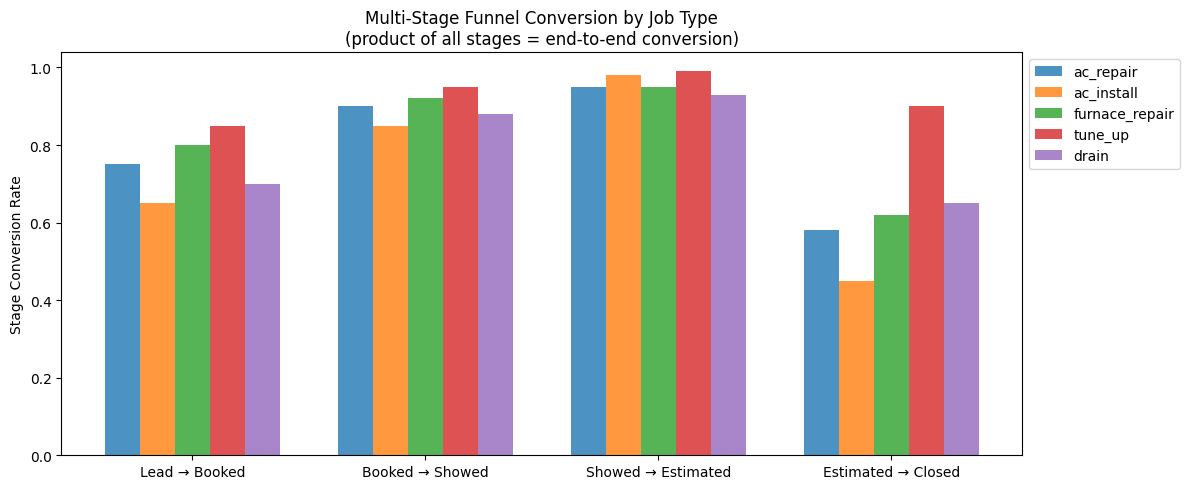

In [5]:
# ─── Simple Multi-Stage Funnel Illustration ──────────────────────────────────
# In a real system, each stage has its own model.
# Here we simulate stage conversion rates by job type.

stages = ['Lead → Booked', 'Booked → Showed', 'Showed → Estimated', 'Estimated → Closed']
conv_rates = {
    'ac_repair':       [0.75, 0.90, 0.95, 0.58],
    'ac_install':      [0.65, 0.85, 0.98, 0.45],
    'furnace_repair':  [0.80, 0.92, 0.95, 0.62],
    'tune_up':         [0.85, 0.95, 0.99, 0.90],
    'drain':           [0.70, 0.88, 0.93, 0.65],
}

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(stages))
width = 0.15

for i, (jtype, rates) in enumerate(conv_rates.items()):
    ax.bar(x + i * width, rates, width, label=jtype, alpha=0.8)
    
    # Print end-to-end conversion
    e2e = np.prod(rates)
    print(f"{jtype:<20}: End-to-end lead → close = {e2e:.1%}")

ax.set_xticks(x + width * 2)
ax.set_xticklabels(stages)
ax.set_ylabel('Stage Conversion Rate')
ax.set_title('Multi-Stage Funnel Conversion by Job Type\n(product of all stages = end-to-end conversion)')
ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('funnel_stages.png', dpi=100, bbox_inches='tight')
plt.show()


## Key Takeaways for Interview

1. **Score at estimate creation time** — tech is still with customer, intervention is still possible
2. **SHAP-driven coaching tips** are more actionable than a raw probability score
3. **Calibrate the model**: if you say 35% close probability, 35% should actually close — business decisions (routing, coaching) depend on it
4. **Multi-stage funnel model** enables marketing ROI calculation: multiply stage conversion rates to get lead value
5. **Tech ID as a feature** captures real closer skill variance — track override rates to see where the model and tech disagree systematically


---
## Why This Problem? Approach Rationale

### Why XGBoost Instead of Logistic Regression or a Neural Net?

Three options were available for this binary classification task:

| Model | Pros | Cons | When to Use |
|---|---|---|---|
| **Logistic Regression** | Interpretable coefficients, fast, calibrated | Misses non-linear interactions (price × job_type) | Baseline, regulated environments |
| **XGBoost (chosen)** | Handles non-linearity, missing values, mixed types; SHAP-compatible | Less interpretable than LR coefficients | When feature interactions matter |
| **Neural Net / Transformer** | Can model complex patterns | Needs far more data, slower to iterate, harder to explain to ops team | Very large datasets (>1M rows) |

The estimate-to-close problem has strong interaction effects — for example, a high price
ratio matters much more for a new customer than a returning one. XGBoost captures these
automatically without manual feature crossing. Logistic Regression would require you to
manually engineer `price_ratio × is_returning` as a feature.

### Why scale_pos_weight?

Close rates in home service are typically 40-60%, but skew lower for high-ticket installs.
`scale_pos_weight = n_negatives / n_positives` tells XGBoost to treat each positive
(closed) sample as if it appeared that many times more. Without it, the model learns to
predict "never closes" on imbalanced data and achieves misleadingly high accuracy.

Alternative: `sample_weight` in sklearn, or threshold tuning after training.
For the coaching use case, recall (catching low-probability estimates) matters more than
precision, which further motivates upweighting the positive class.

### Why Calibration Matters Here

A model that says "70% close probability" but only converts at 40% is miscalibrated.
The business consequence: the follow-up routing system would not call back estimates
it should — because it thinks they're already likely to close.

The Platt scaling / isotonic regression calibration step (sklearn's `CalibratedClassifierCV`)
maps raw model scores to true probabilities. Always check the calibration curve before
deploying a score into a business decision system.


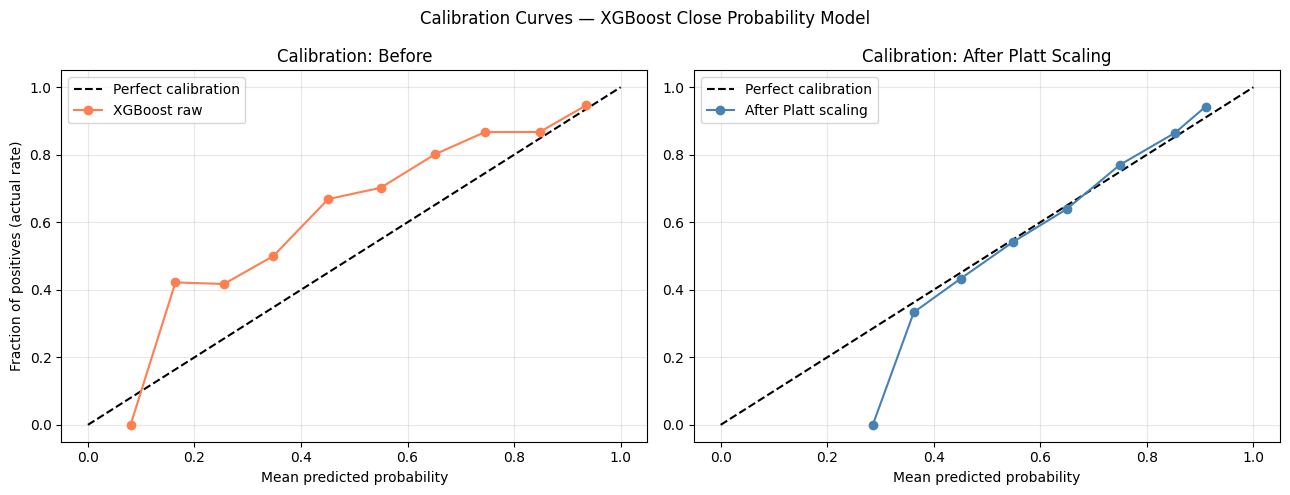

Before calibration - mean predicted: 0.548, actual rate: 0.684
After calibration  - mean predicted: 0.682, actual rate: 0.684


In [6]:
# ── Why calibration matters: visual demonstration ─────────────────────────────
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import matplotlib.pyplot as plt
import numpy as np

# The model was trained in earlier cells — probs are the raw XGBoost outputs
# Let's visualize and then apply calibration

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before calibration
fraction_of_positives, mean_predicted = calibration_curve(y_te, probs, n_bins=10)
axes[0].plot([0,1],[0,1], 'k--', label='Perfect calibration')
axes[0].plot(mean_predicted, fraction_of_positives, 'o-', color='coral', label='XGBoost raw')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives (actual rate)')
axes[0].set_title('Calibration: Before')
axes[0].legend(); axes[0].grid(alpha=0.3)

# After calibration (Platt scaling = sigmoid)
calibrated = CalibratedClassifierCV(model, cv=3, method='sigmoid')
calibrated.fit(X_tr, y_tr)   # fit on training data — in production use a held-out calibration set
probs_cal = calibrated.predict_proba(X_te)[:, 1]

fop_cal, mpv_cal = calibration_curve(y_te, probs_cal, n_bins=10)
axes[1].plot([0,1],[0,1], 'k--', label='Perfect calibration')
axes[1].plot(mpv_cal, fop_cal, 'o-', color='steelblue', label='After Platt scaling')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_title('Calibration: After Platt Scaling')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Calibration Curves — XGBoost Close Probability Model', fontsize=12)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Before calibration - mean predicted: {probs.mean():.3f}, actual rate: {y_te.mean():.3f}")
print(f"After calibration  - mean predicted: {probs_cal.mean():.3f}, actual rate: {y_te.mean():.3f}")


---
## Interview Q&A — Lead-to-Close Funnel

---

**Q: Why use a classification model rather than just tracking conversion rates by job type?**

A: Conversion rates by job type are a good baseline but miss the interaction effects that
matter most. A $4,500 AC install has very different close rates depending on whether
the customer is new vs. returning, whether financing was offered, and how the quote
compares to market rate. A model that combines these signals predicts individual estimate
outcomes much better than a per-job-type average. The model also updates as tech
performance changes over time — a lookup table doesn't.

---

**Q: Your model predicts probability of close. How do you decide which estimates to route for follow-up?**

A: This is a threshold decision, and the right threshold depends on the business's
capacity for follow-up calls. If the call center can handle 20 callbacks per day, I'd
rank all open estimates by close probability, flag the bottom N where `N` is the
operational budget, and route those. Using a fixed threshold (e.g., `< 0.4`) is simpler
but ignores capacity constraints. Precision@K framing is cleaner: "of the 20 estimates
we call back, how many do we recover?" — that's more actionable than ROC-AUC for ops.

---

**Q: Why PR-AUC rather than ROC-AUC as your primary metric?**

A: If close rates are imbalanced (say 35% close), ROC-AUC can look high even if the
model mostly predicts the majority class. PR-AUC focuses on the positive class — in this
case, closed estimates. Since the business cares specifically about correctly identifying
and recovering lost sales, PR-AUC is more sensitive to what actually matters. In practice
I'd report both: ROC-AUC for overall discrimination, PR-AUC for the actionable use case.

---

**Q: How would you handle the feedback loop? If coaching tips change tech behavior, your training data shifts.**

A: This is a classic label leakage / distribution shift problem. Two mitigations:
1. **Logging**: Record whether a coaching tip was shown for each estimate. Add an
   `intervention_shown` flag to the training data so the model can distinguish natural
   outcomes from coached ones.
2. **Holdout control group**: Route a small fraction (5-10%) of low-probability estimates
   to *not* show coaching tips. This maintains a baseline to measure the tip's actual lift,
   and provides unbiased training examples for future model versions.

---

**Q: What alternatives did you consider for the coaching tip generation?**

A: Three options in increasing sophistication:
1. **Rule-based (current approach)**: SHAP identifies the top negative feature → hardcoded
   tip template. Fast, explainable, no extra model needed.
2. **LLM-generated tips**: Pass the SHAP top features and estimate context to GPT-4 and
   generate a natural language coaching suggestion. More personalized but adds latency and cost.
3. **RL-trained tip selection**: Track which tip types lead to conversions and use a bandit
   algorithm to learn which tip to show per context. Most sophisticated but needs a lot of data.
   For a new deployment, option 1 is the right starting point.
